# 1. Problem Statement

The data examining anonymized patients who have received a diagnosis of heart disease. By identifying patients who share similar characteristics, we can gain insights into the effectiveness of specific treatments. This information would be valuable for doctors, as they could learn from the outcomes of patients similar to those they are treating. The dataset originates from the V.A. Medical Center in Long Beach, California.

The objective is to cluster similar charecteristics having patients for effective specific treatments.

Kaggle Competition Link : https://www.kaggle.com/competitions/k-means-clustering-for-heart-disease-analysis

# 2. Understanding Data

| S. No | Feature | Type | Description | Units |
|-------|---------|------|-------------|-------|
| 1 | id | Discrete | id of the patient | |	
| 2 | age | Discrete | age years | |
| 3	| sex | Categorical | sex of the patient (1=male, 0=female) | |	
| 4	| dataset |	Categorical	| origin of instance | |
| 5 | cp | Categorical | chest pain type | |
| 6	| trestbps | Discrete | resting blood pressure | mm Hg |
| 7 | chol | Discrete | cholesterol measurement | mg/dl |
| 8	| fbs | Categorical | fasting blood sugar > 120 mg/dl | |
| 9	| restecg | Categorical | resting electrocardiographic results | |
| 10 | thalach | Discrete | maximum heart rate achieved	| |
| 11 | exang | Categorical | exercise induced angina (1 = yes, 0 = no) | |
| 12 | oldpeak | Discrete | ST depression induced by exercise relative to rest | |
| 13 | slope | Categorical | slope of the peak exercise ST segment | |
| 14 | ca | Discrete | number of major vessels (0-3) | |
| 15 | thal	| Categorical | a blood disorder called thalassemia | |

# 3. Importing Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/k-means-clustering-for-heart-disease-analysis/heart_disease.csv
/kaggle/input/competitions/k-means-clustering-for-heart-disease-analysis/sample.csv


# 4. Exploratory Data Analysis

In [2]:
df = pd.read_csv("/kaggle/input/competitions/k-means-clustering-for-heart-disease-analysis/heart_disease.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [4]:
df.isna().sum() * 100/len(df)

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
dtype: float64

### Insights From The DataFrame:
- There are 920 Rows and 15 Columns.
- There are 8 categorical values and 7 numerical values.
- There is no data type mismatch.
- Most of the columns have present the null values.
- There are moderate level null values in these columns (trestbps, chol, fbs, restecg, thalch, exang, oldpeak).
- There are high percentage of null values present in columns (slope, ca, thal).

### Suggestions :
- Impute the null values.
- - for normally distributed numerical values - Mean.
  - for skewed numerical values - Median.
  - for categorical values - Mode.
- High amount of null values presenting columns may or maynot be removed. further evaluation needed.

## Statistical Analysis

In [5]:
df.describe(include = 'all')

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196
mean,459.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN
min,0.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN
25%,229.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN
50%,459.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN
75%,689.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN


### Insights :
- 1. **Age** :
     - Ranges From 28 to 77 (mean = 53.5)
     - Middle Aged Patients Data.
     - Moderate Spread With Standard Deviation = 9.4
- 2. **trestbps (Resting Blood Pressure)** :
     - Ranges from 0 - 200 (Mean = 132.1)
     - Blood pressure will not be zero for a living body. Need to convert.
     - Mean 132.1 represents slightly above normal resting blood pressure.
- 3. **chol (Cholesterol)** :
     - Ranges From 0 to 603 (Mean = 199.1).
     - Zero for the cholesterol is impossible.
     - standard deviation 110 represents high variations.
- 4. **thalch (Maximum Heart Rate)** :
     - Ranges From 60 to 202 (Mean = 137.5).
     - typical stress-test patients maximum heart rate of mean.
- 5. **oldpeak (ST Depression)** :
     - Ranges From -2.6 to 6.2
- 6. **ca (Number of Major Blockage Vessels)** :
     - Ranges from 0 to 3.
    
### Suggestions :
- Convert Zero values in trestbps, chol to correspond imputes.


In [6]:
print(df.duplicated().sum())

0


- No Duplicates Present

## Preprocessing

- The High null value presence need to be imputed. because of the importance of the feature (Going with KNN imputing)
- The moderate null values imputed by simple imputation.
- convert zero values in trestbps, chol

In [7]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_features = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Handling Medium level null values

numerical_imputer = SimpleImputer(strategy = 'median')
impute_col = [col for col in numerical_features if col != 'ca']

df[impute_col] = numerical_imputer.fit_transform(df[impute_col])

categorical_imputer = SimpleImputer(strategy = 'most_frequent')
impute_col = [col for col in categorical_features if col not in ['slope', 'thal']]

df[impute_col] = categorical_imputer.fit_transform(df[impute_col])

df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,0,63.0,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,1,67.0,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,2,67.0,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,3,37.0,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,4,41.0,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,915,54.0,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN
916,916,62.0,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,NaN,NaN,NaN
917,917,55.0,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect
918,918,58.0,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    float64
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    object 
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    object 
 11  oldpeak   920 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
dtypes: float64(6), int64(1), object(8)
memory usage: 107.9+ KB


## Univariate Analysis.

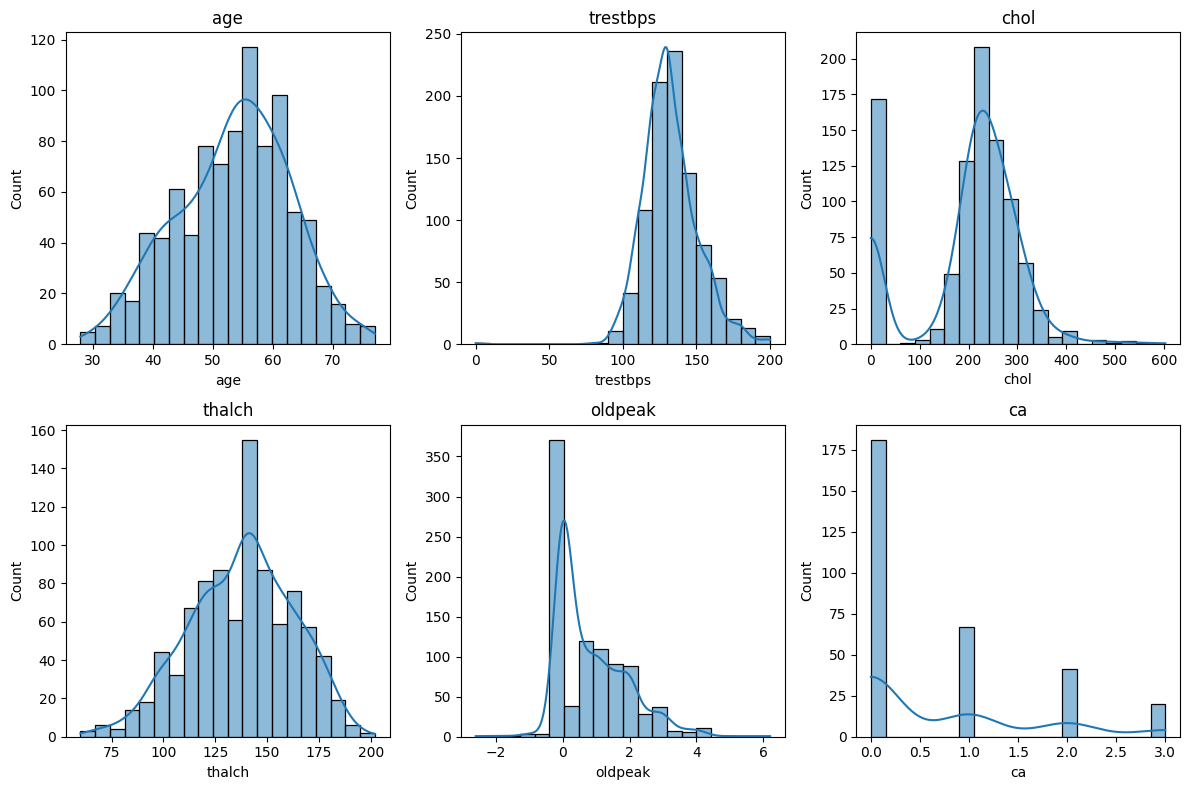

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_features) :
    sns.histplot(df[col], bins=20, ax = axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Insights :
- Most of the patients are Middle aged.
- The Highest counts are between 50 and 60 Years.
- The distribution is roughly normal
------------------------------------------

- Most Patients have bp of 120 to 150.
- Slightly right skewed.
- there is bp with zero patients.
- high bp patients are comparitively low.
------------------------------------------

- The first peak in the cholesterol shows incorrectness.
- More Patients have 200 to 250 level of cholesterol.
- Extremely High Cholesterol are very less.
------------------------------------------

- Most Patients Heart rate between 120 to 160.
- The Heart rate shows a normal distribution.
------------------------------------------

- Most peoples have zero level of old peak.
- -2 to 0 and 3-6 are rare.
------------------------------------------

- The majority vessels ca have most patients with zero.
  

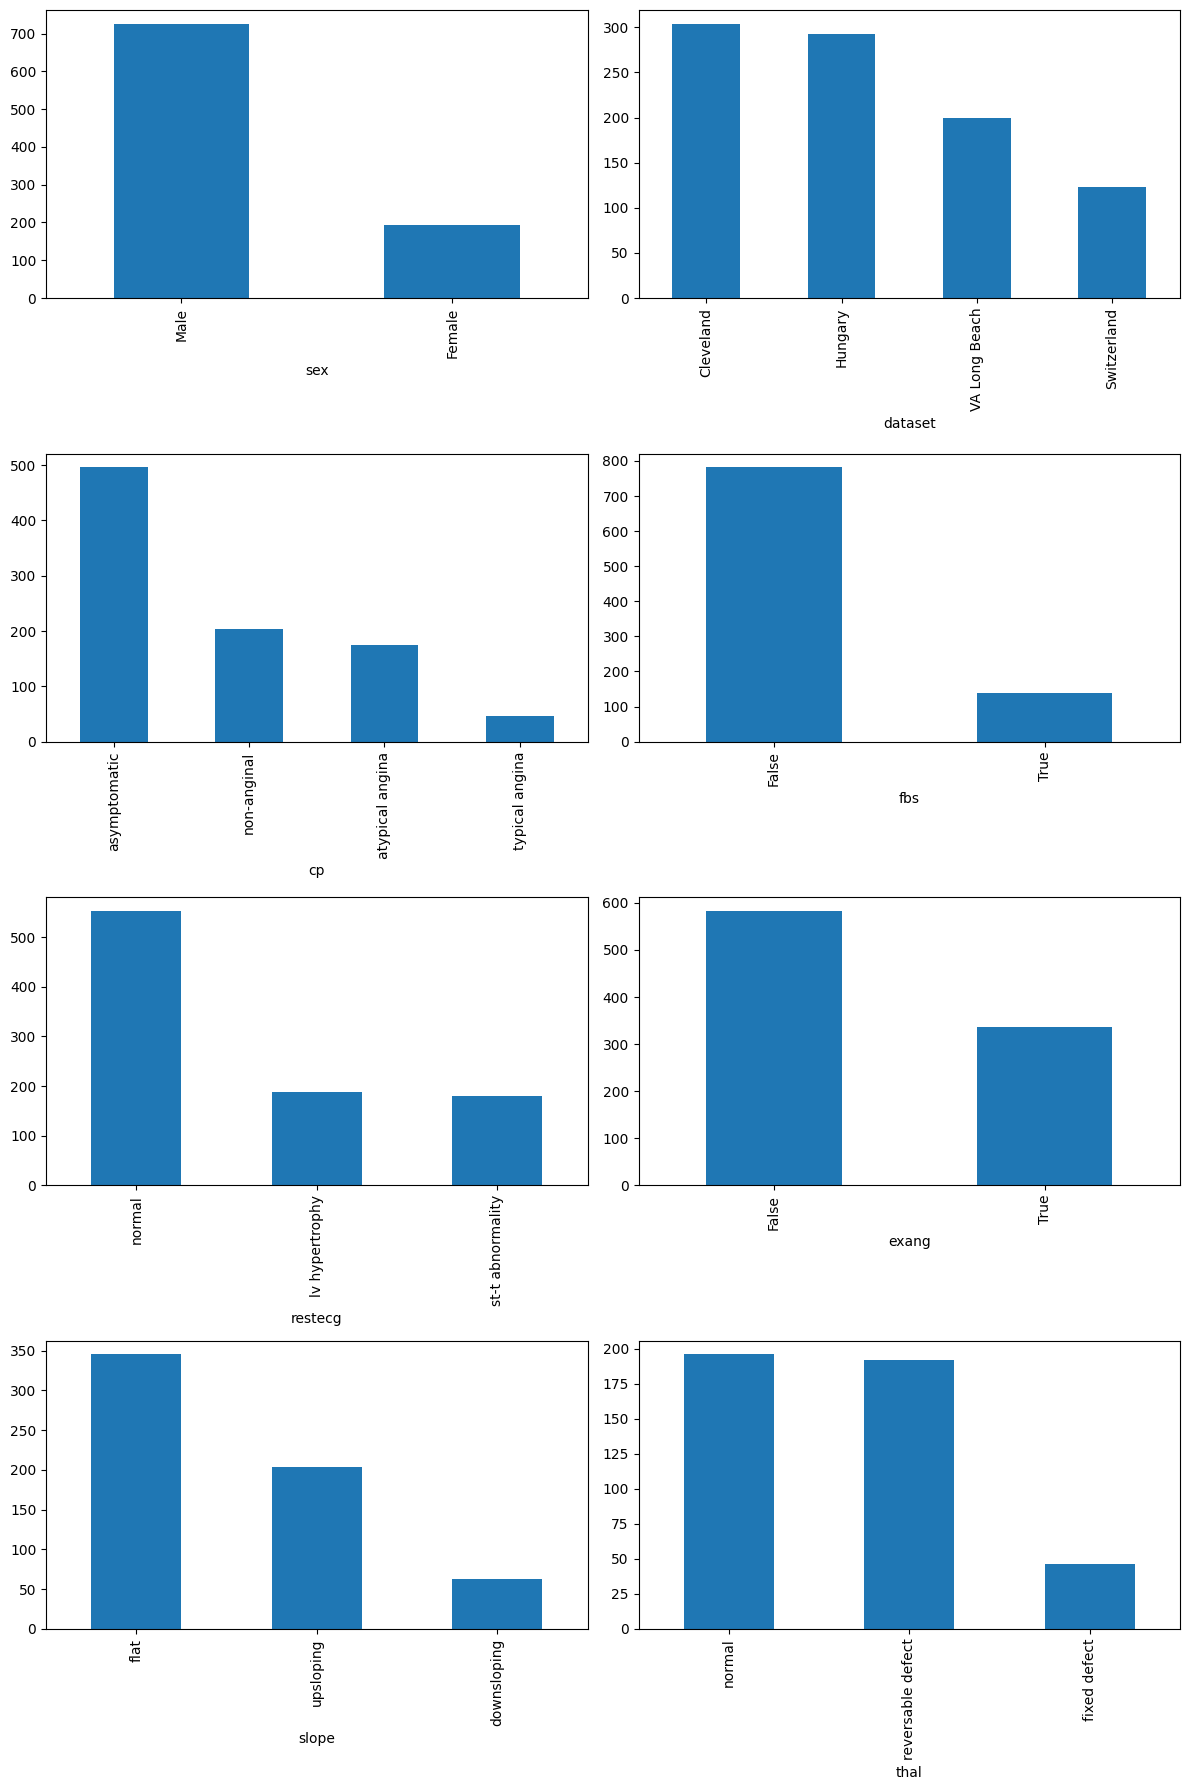

In [10]:
categorical_features = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


fig, axes = plt.subplots(4, 2, figsize=(12, 18))
axes = axes.flatten()
for i, col in enumerate(categorical_features) :
    df[col].value_counts().plot(kind = 'bar', ax = axes[i])
plt.tight_layout()
plt.show()

### Insights :
- The data contain Male Individuals More than Females
- Cleveland and Hungary dataset showing more Datas than switzerland.
- Most of the data showing normal.

- ### Outlier Detection.

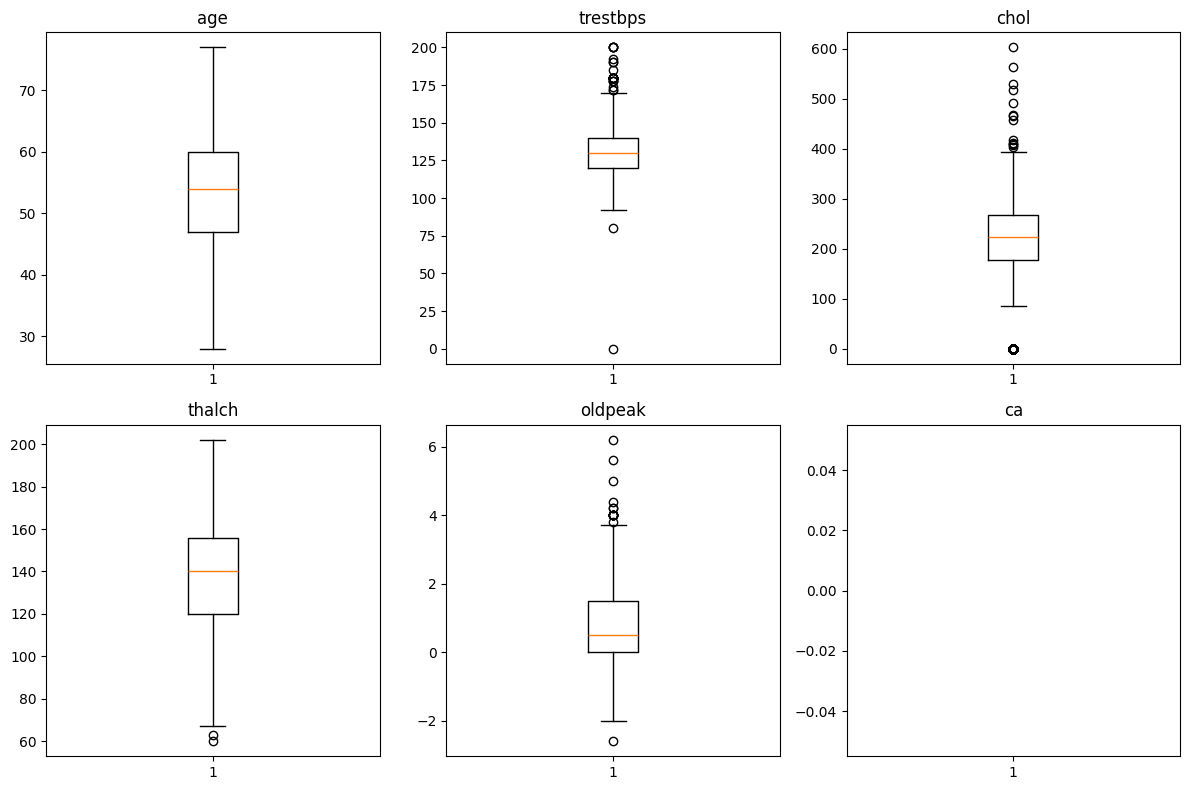

In [11]:
import matplotlib.pyplot as plt

numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_features) :
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Insights.
- There are outliers in trestbps, chol, thalch, oldpeak.

### Suggestion :
- The chol, trestbps the lowest values that is Zero need to be converted.
- The else are naturally possible to happen.

## Correlation Analysis

In [12]:
from sklearn.preprocessing import OneHotEncoder

heart_disease_df = pd.get_dummies(df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']], drop_first=True, dtype = int)
heart_disease_df

,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,0.0,1,0,0,1,1,0,0,0,0,0,0,0
1,67.0,160.0,286.0,108.0,1.5,3.0,1,0,0,0,0,0,0,1,1,0,1,0
2,67.0,120.0,229.0,129.0,2.6,2.0,1,0,0,0,0,0,0,1,1,0,0,1
3,37.0,130.0,250.0,187.0,3.5,0.0,1,0,1,0,0,1,0,0,0,0,1,0
4,41.0,130.0,204.0,172.0,1.4,0.0,0,1,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.0,127.0,333.0,154.0,0.0,NaN,0,0,0,0,1,0,1,0,0,0,0,0
916,62.0,130.0,139.0,140.0,0.5,NaN,1,0,0,1,0,0,1,0,0,0,0,0
917,55.0,122.0,223.0,100.0,0.0,NaN,1,0,0,0,1,0,1,0,0,0,0,0
918,58.0,130.0,385.0,140.0,0.5,NaN,1,0,0,0,1,0,0,0,0,0,0,0


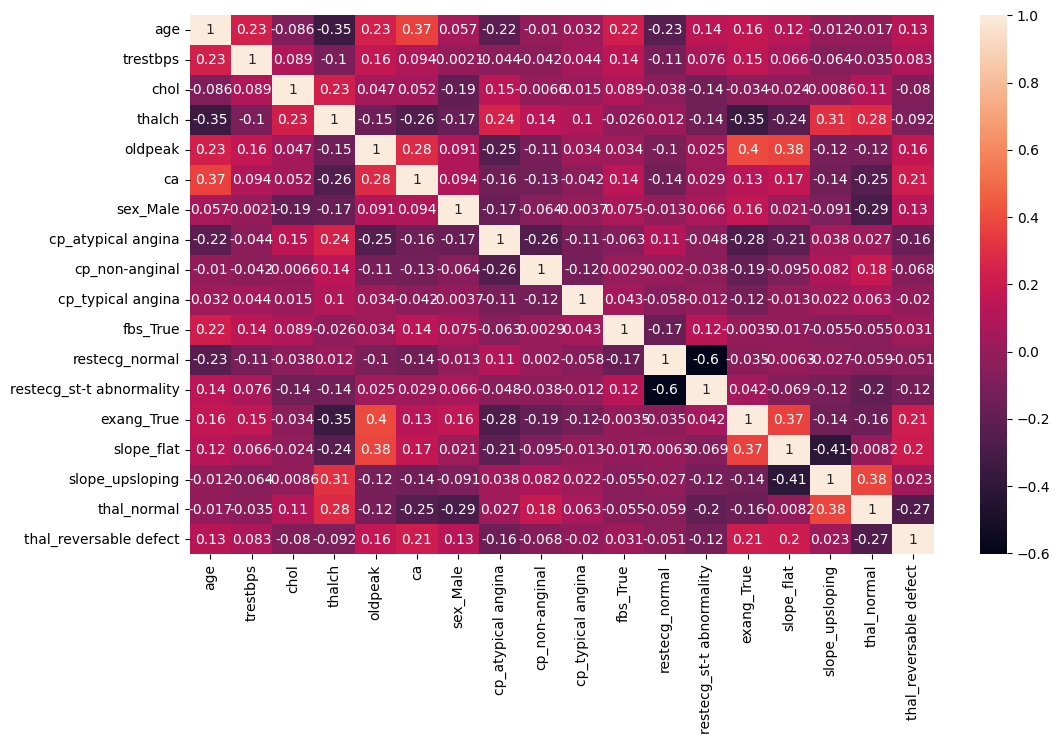

In [13]:
df_corr = heart_disease_df

plt.figure(figsize = (12,7))
sns.heatmap(df_corr.corr(), annot = True)
plt.show()

### Insights :
- Excercise angina is highly correlated with oldpeak.
- Max heart rate have strong -ve correlation with age.
- Number of vessels (ca) is highly correlated with age.
- Multi Collineariy can be visible through dummy variable trap (0.6).


- **Strong Features**
    - oldpeak
    - ca
    - thalch
    - slope
    - exang

- **Moderate Features**
    - cp
    - thal
    - age
- **Weak Features**
    - chol
    - trestbps
    - fbs

# 5. Final Insights



| Issues | Insights | Actions |
|--------|----------|---------|
| Missing Values | These features are clinically important, so dropping them is not ideal. | SimpleImputer for moderate-missing columns, treat others as unknown. |
| Invalid Values (trestbps = 0, chol = 0) | Need to impute | change into null then impute |

- As Mentioned in the problem go for KMeans.
- Avoid KNN Imputation on columns having high percentage of null values due to the problems like.
    - distance distortion.
    - bias amplification.
- Change the null values in high percentage as -1 for numeric and unknown for categorical.
- Drop non-informative datas (id).
- Go for OneHotEncoding for categorical values.
- Scale the datas for kmeans.

----------------------------
Proof Of Concept Is Over
-----------------------------

# 6. Model Pipeline Building

In [14]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# Loading Data

heart_disease_df = pd.read_csv("/kaggle/input/competitions/k-means-clustering-for-heart-disease-analysis/heart_disease.csv")

# Data Cleaning

df = heart_disease_df.drop(columns=['id'])

# Replacing Impossible Values From the data

df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['chol'] = df['chol'].replace(0, np.nan)

num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# High Percentage missing values Handling

df['ca_missing'] = df['ca'].isna().astype(int)
df['ca'] = df['ca'].fillna(-1)

num_cols_extended = num_cols + ['ca', 'ca_missing']

for col in ['slope', 'thal']:
    df[col] = df[col].fillna("Unknown")

# Pipelines For Preprocessing

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop = 'first'))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols_extended),
    ('cat', cat_pipeline, cat_cols)
])


# Model Pipelining

def model_function(n_cluster = 5):
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('kmeans', KMeans(n_clusters=n_cluster, random_state=42, n_init=10))
    ])
    return model

# 7. Number of Clusters Selection.

## Using Inertia
It is how compact your clusters are
Inertia = sum of squared distances of points from their cluster center

Low inertia → points are close to cluster center → good clustering
High inertia → points are spread out → bad clustering

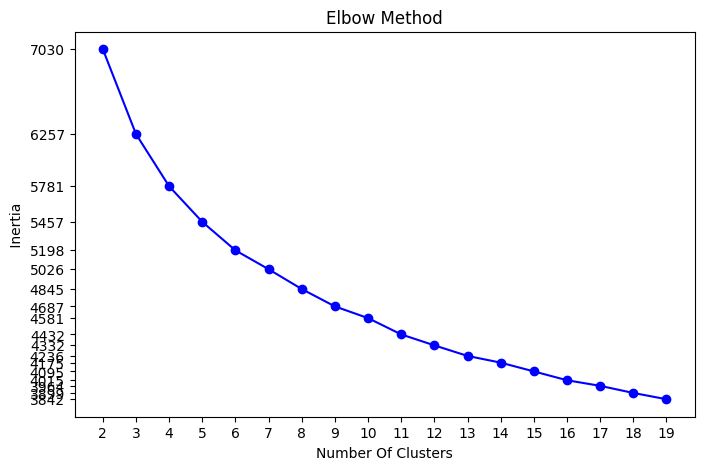

In [15]:
inertia = []
for k in range(2, 20):
    model = model_function(n_cluster = k)
    model.fit(df)
    inertia.append(model['kmeans'].inertia_)

plt.figure(figsize = (8, 5))
plt.plot([k for k in range(2, 20)], inertia, 'bo-')
plt.title("Elbow Method")
plt.xticks([k for k in range(2, 20)])
plt.yticks(inertia)
plt.xlabel("Number Of Clusters")
plt.ylabel(" Inertia ")
plt.show()

### Finding The Best K

- The K value from 2 to 5 a significance big drop in inertia.
- After the k value 5 the drop becomes lesser.

## Using Silhoutte Score
Silhouette Score measures how good your clusters are

For each point, it checks:
1. How close it is to its own cluster
2. How far it is from other clusters

| Value       | Meaning              |
| ----------- | -------------------- |
| Close to +1 | Very good clustering |
| Around 0    | Overlapping clusters |
| Negative    | Wrong clustering     |

NOTE: Silhouette score must be calculated on transformed data, not raw data



In [16]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    model = model_function(n_cluster=k)
    
    labels = model.fit_predict(df)
    
    X_transformed = model.named_steps['preprocessor'].transform(df)
    
    score = silhouette_score(X_transformed, labels)
    
    print(f"No. of clusters: {k}, Silhouette Score: {score:.4f}")

No. of clusters: 2, Silhouette Score: 0.2255
No. of clusters: 3, Silhouette Score: 0.1536
No. of clusters: 4, Silhouette Score: 0.1560
No. of clusters: 5, Silhouette Score: 0.1404
No. of clusters: 6, Silhouette Score: 0.1438
No. of clusters: 7, Silhouette Score: 0.1284
No. of clusters: 8, Silhouette Score: 0.1240
No. of clusters: 9, Silhouette Score: 0.1261


### Finding the best K
- The Silhouette score represents the seperation of the clusters.
- It shows at 2 clusters the seperation is well.

#### Final Decision :
- Taking The Optimal K as 4. for better cluster quality and compactness of the datas within cluster.

# 8. Fitting With Optimal K = 4

In [17]:
optimal_k = 4
model = model_function(optimal_k)
labels = model.fit_predict(df)
centers = model['kmeans'].cluster_centers_
heart_disease_df['cluster'] = labels

print(centers)

[[-8.64419043e-01 -3.33233169e-01 -6.57183756e-02  3.67961886e-01
  -5.34211965e-01 -5.87033006e-01  7.11145776e-01  7.36842105e-01
   7.81954887e-01  1.24060150e-01  7.51879699e-02  3.64661654e-01
   2.36842105e-01  3.75939850e-02  6.01503759e-02  8.00751880e-01
   1.72932331e-01  1.57894737e-01  2.25563910e-02  1.61654135e-01
   9.39849624e-02  4.51127820e-02  5.26315789e-02  7.14285714e-02]
 [ 6.26018803e-01  1.87669692e-01  8.97731496e-02 -2.10587409e-01
   9.99305529e-01  1.70670214e+00 -1.40618145e+00  7.84615385e-01
   7.69230769e-03  3.84615385e-02  1.53846154e-02  3.07692308e-02
   1.61538462e-01  1.00000000e-01  1.61538462e-01  3.76923077e-01
   5.38461538e-02  5.92307692e-01  1.15384615e-01  7.38461538e-01
   1.38461538e-01  1.15384615e-01  2.61538462e-01  5.76923077e-01]
 [ 5.58427780e-01  2.78330207e-01  3.50087982e-02 -6.78501762e-01
   2.50871394e-01 -5.87033006e-01  7.11145776e-01  9.21739130e-01
   2.37681159e-01  2.46376812e-01  5.15942029e-01  7.82608696e-02
   1.623

# 9. Visualizing Clusters.

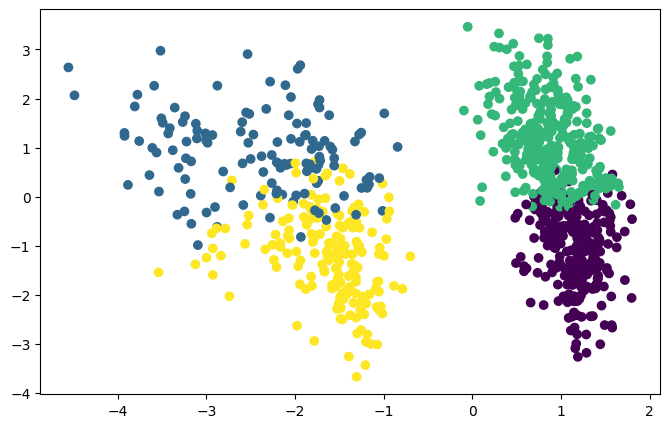

In [18]:
from sklearn.decomposition import PCA

data = model['preprocessor'].fit_transform(df)
pca = PCA(n_components = 0.90, random_state = 42)
X_pca = pca.fit_transform(data)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:, 1], c = labels)
plt.show()